# This script will produce a plot of integrated outward flux as a function of RMW and V

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# This works when Jupyter starts in either the repository root or plots/.
cwd = Path.cwd().resolve()
repo_root = next(
    (path for path in (cwd, *cwd.parents) if (path / "src" / "config.yaml").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

output_dir = repo_root / "outputs"
snapshot_dir = output_dir / "snapshots"
print(f"Reading model output from {output_dir}")

Reading model output from /geode3/home/u020/ckieu/BigRed200/model/vortex-waves/outputs


ValueError: x and y must have same first dimension, but have shapes (49,) and (27,)

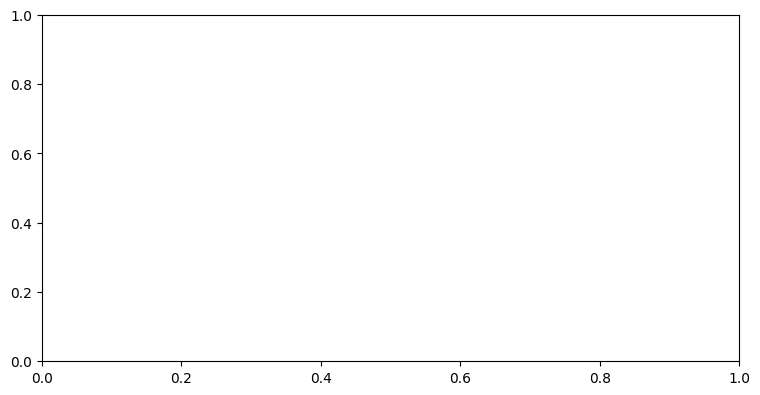

In [4]:
RMW = 50.0
Vmax = 50.0
power_path = output_dir / f"power_flux_timeseries_{Vmax}_{RMW}.csv"
if not power_path.exists():
    raise FileNotFoundError(f"Run the model first; missing {power_path}")

power_data = np.atleast_1d(np.genfromtxt(power_path, delimiter=",", names=True))
time_hours = power_data["time_s"] / 3600.0

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(time_hours[:max_time], power_data["power_W"][:max_tim], color="tab:blue", linewidth=2)
ax.axhline(0.0, color="0.35", linewidth=0.8)
ax.set(
    xlabel="Simulation time (h)",
    ylabel="Outward power flux (W)",
    title="Perturbation power flux through the diagnostic circle",
)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()